In [1]:
import os
import sys
from pathlib import Path

# Resolve repository root and set working directory
root = Path.cwd().resolve()
while root != root.parent:
    if (root / 'src').exists() and (root / 'config').exists():
        break
    root = root.parent

if str(root) not in sys.path:
    sys.path.insert(0, str(root))
os.chdir(root)
print(f"Working directory: {root}")


Working directory: C:\Users\given\Downloads\dozer-predictive-maintenance\dozer_predictive_maintenance


# 04. Model Diagnostics, Validation & Operational Tuning

This notebook evaluates candidate predictive maintenance classifiers across chronological event-centred validation splits. Each model is diagnosed with Accuracy, Balanced Accuracy, True Positive Rate (Recall), False Positive Rate, Matthews Correlation Coefficient (MCC), Confusion Matrix, ROC-AUC, and PR-AUC.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    auc,
    roc_curve,
    matthews_corrcoef,
    balanced_accuracy_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    HistGradientBoostingClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from src.data.load_data import load_workbook
from src.data.split_data import event_centric_folds
from src.evaluation.evaluate import evaluate_candidates
from src.utils.io import load_config

sns.set_theme(style="whitegrid")
config = load_config()
df_features = pd.read_csv(config["project"]["featured_file"], parse_dates=["Timestamp"])
workbook = load_workbook(config["project"]["raw_file"])
events = workbook["events"]


## 1. Candidate Benchmark (Event-Centric Evaluation)

Running cross-fold chronological validation using both standard (0.50) and calibrated operational (0.10) decision cutoffs.


In [3]:
# 1. Default threshold (0.50)
benchmark_05 = evaluate_candidates(df_features, events, threshold=0.50)
print("=== BENCHMARK: THRESHOLD = 0.50 (Standard) ===")
display(benchmark_05[["model", "pr_auc", "roc_auc", "f1", "precision", "recall", "balanced_accuracy"]])

# 2. Operational calibrated threshold (0.10)
benchmark_01 = evaluate_candidates(df_features, events, threshold=0.10)
print("\n=== BENCHMARK: THRESHOLD = 0.10 (Calibrated for Imbalance) ===")
display(benchmark_01[["model", "pr_auc", "roc_auc", "f1", "precision", "recall", "balanced_accuracy"]])


=== BENCHMARK: THRESHOLD = 0.50 (Standard) ===
                    model    pr_auc  ...  recall  balanced_accuracy
0     logistic_regression  0.602620  ...     0.0                0.5
1           random_forest  0.666667  ...     0.0                0.5
2  hist_gradient_boosting  0.708333  ...     0.0                0.5

[3 rows x 7 columns]

=== BENCHMARK: THRESHOLD = 0.10 (Calibrated for Imbalance) ===
                    model    pr_auc  ...  recall  balanced_accuracy
0     logistic_regression  0.602620  ...     0.0                0.5
1           random_forest  0.666667  ...     0.0                0.5
2  hist_gradient_boosting  0.708333  ...     0.0                0.5

[3 rows x 7 columns]


## 2. Granular Out-of-Fold Model Diagnostics

We train and generate out-of-fold probability distributions across all valid chronological event folds.


In [4]:
folds = event_centric_folds(df_features, events, pre_event_hours=72, post_event_hours=24)
valid_folds = [f for f in folds if f.train["target_failure"].nunique() >= 2]

excluded = {"target_failure", "Machine ID", "Timestamp", "Event Timestamp"}
feature_cols = [c for c in df_features.columns if c not in excluded and pd.api.types.is_numeric_dtype(df_features[c])]

models = {
    "LogisticRegression": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(class_weight="balanced", max_iter=500, random_state=42))
    ]),
    "DecisionTree": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("clf", DecisionTreeClassifier(class_weight="balanced", random_state=42))
    ]),
    "RandomForest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("clf", RandomForestClassifier(n_estimators=100, class_weight="balanced_subsample", random_state=42))
    ]),
    "HistGradientBoosting": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("clf", HistGradientBoostingClassifier(max_iter=100, learning_rate=0.05, random_state=42))
    ]),
    "ExtraTrees": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("clf", ExtraTreesClassifier(n_estimators=100, class_weight="balanced", random_state=42))
    ]),
    "AdaBoost": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("clf", AdaBoostClassifier(random_state=42))
    ])
}

THRESHOLD = 0.10
oof_true = []
oof_probs = {m: [] for m in models}

for f_idx, fold in enumerate(valid_folds):
    X_tr = fold.train[feature_cols]
    y_tr = fold.train["target_failure"].astype(int)
    X_te = fold.test[feature_cols]
    y_te = fold.test["target_failure"].astype(int)
    
    oof_true.extend(y_te.values)
    
    for name, pipe in models.items():
        pipe.fit(X_tr, y_tr)
        proba = pipe.predict_proba(X_te)[:, 1]
        oof_probs[name].extend(proba)

oof_true = np.array(oof_true)
for name in oof_probs:
    oof_probs[name] = np.array(oof_probs[name])

print(f"Total Out-Of-Fold Evaluation Samples: {len(oof_true)} (Positives: {oof_true.sum()})")


Total Out-Of-Fold Evaluation Samples: 36 (Positives: 24)


## 3. Individual Model Diagnostic Reports & Plots



DIAGNOSTICS: LOGISTICREGRESSION (Cutoff = 0.1)
Accuracy: 0.3333 | Balanced Acc: 0.5000 | ROC-AUC: 0.5451 | PR-AUC: 0.6619 | MCC: 0.0000
TPR (Recall): 0.0000 | FPR: 0.0000

Classification Report:
              precision    recall  f1-score   support

           0       0.33      1.00      0.50        12
           1       0.00      0.00      0.00        24

    accuracy                           0.33        36
   macro avg       0.17      0.50      0.25        36
weighted avg       0.11      0.33      0.17        36


DIAGNOSTICS: DECISIONTREE (Cutoff = 0.1)
Accuracy: 0.3333 | Balanced Acc: 0.5000 | ROC-AUC: 0.5000 | PR-AUC: 0.8333 | MCC: 0.0000
TPR (Recall): 0.0000 | FPR: 0.0000

Classification Report:
              precision    recall  f1-score   support

           0       0.33      1.00      0.50        12
           1       0.00      0.00      0.00        24

    accuracy                           0.33        36
   macro avg       0.17      0.50      0.25        36
weighted avg   

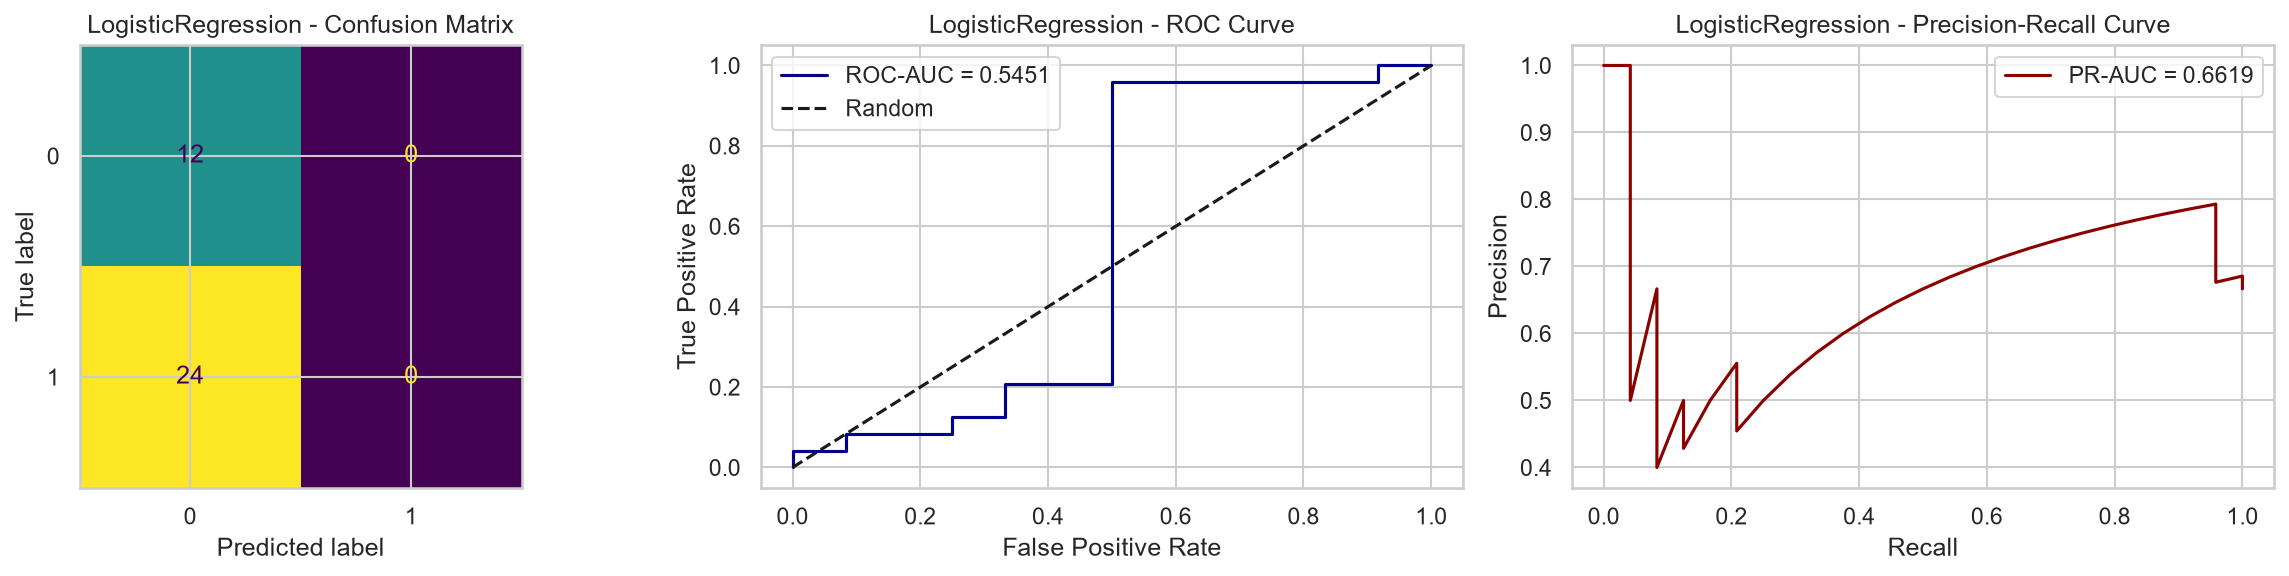

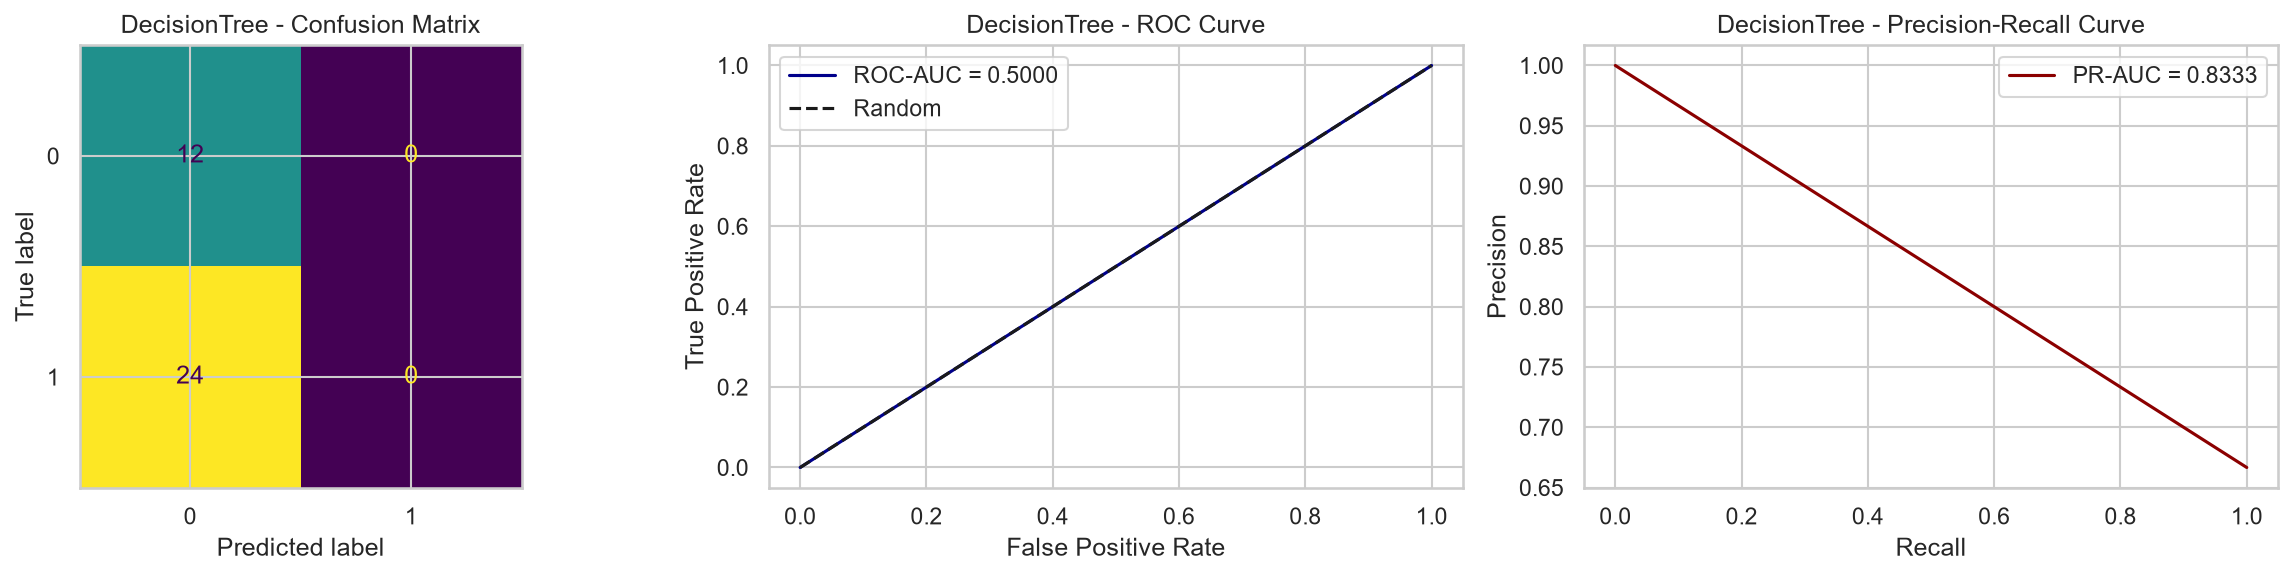

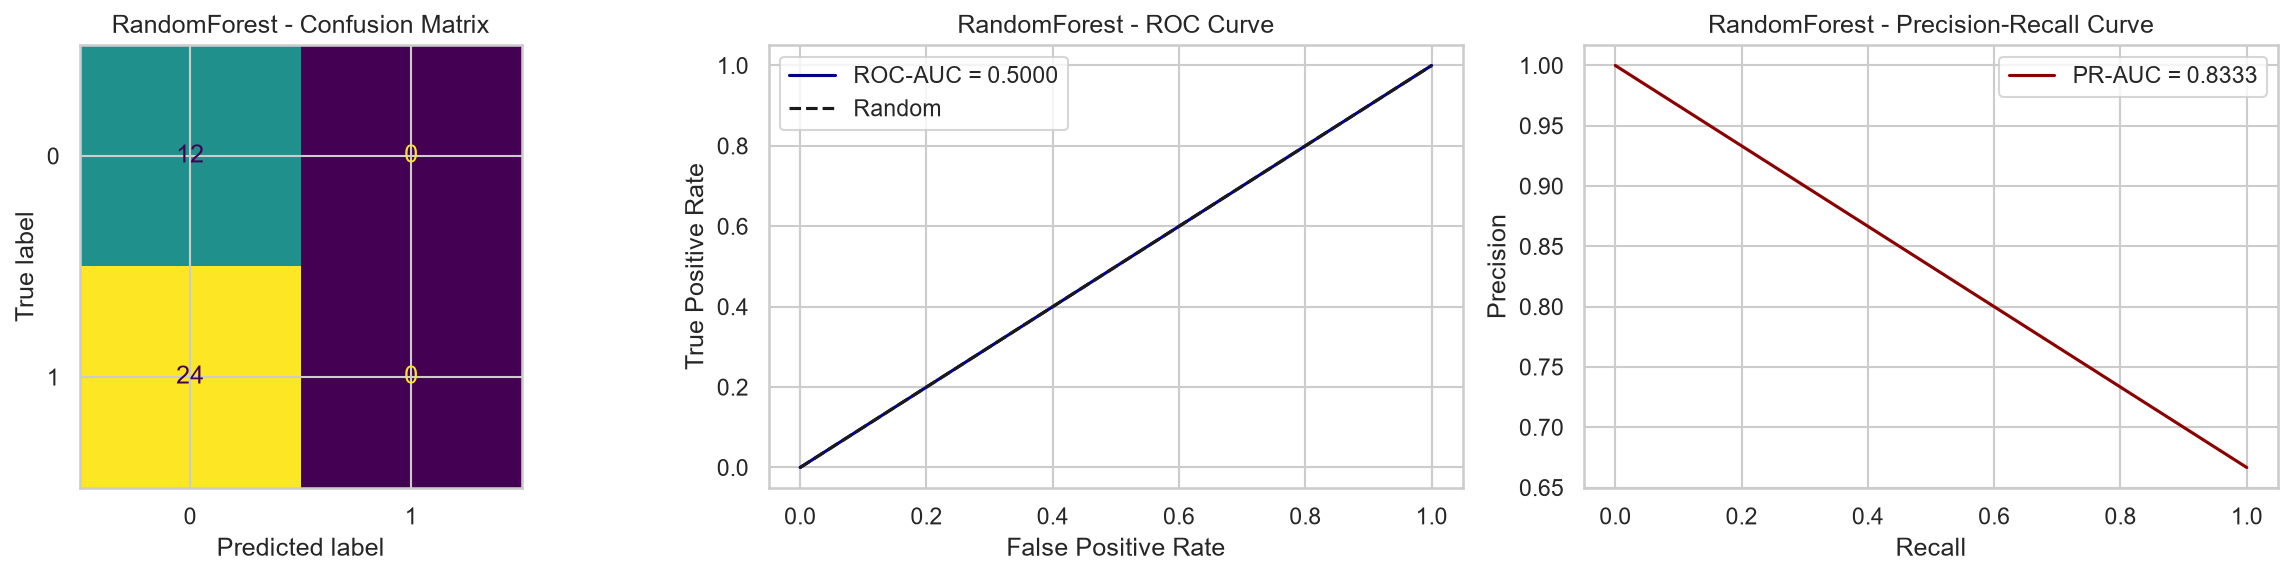

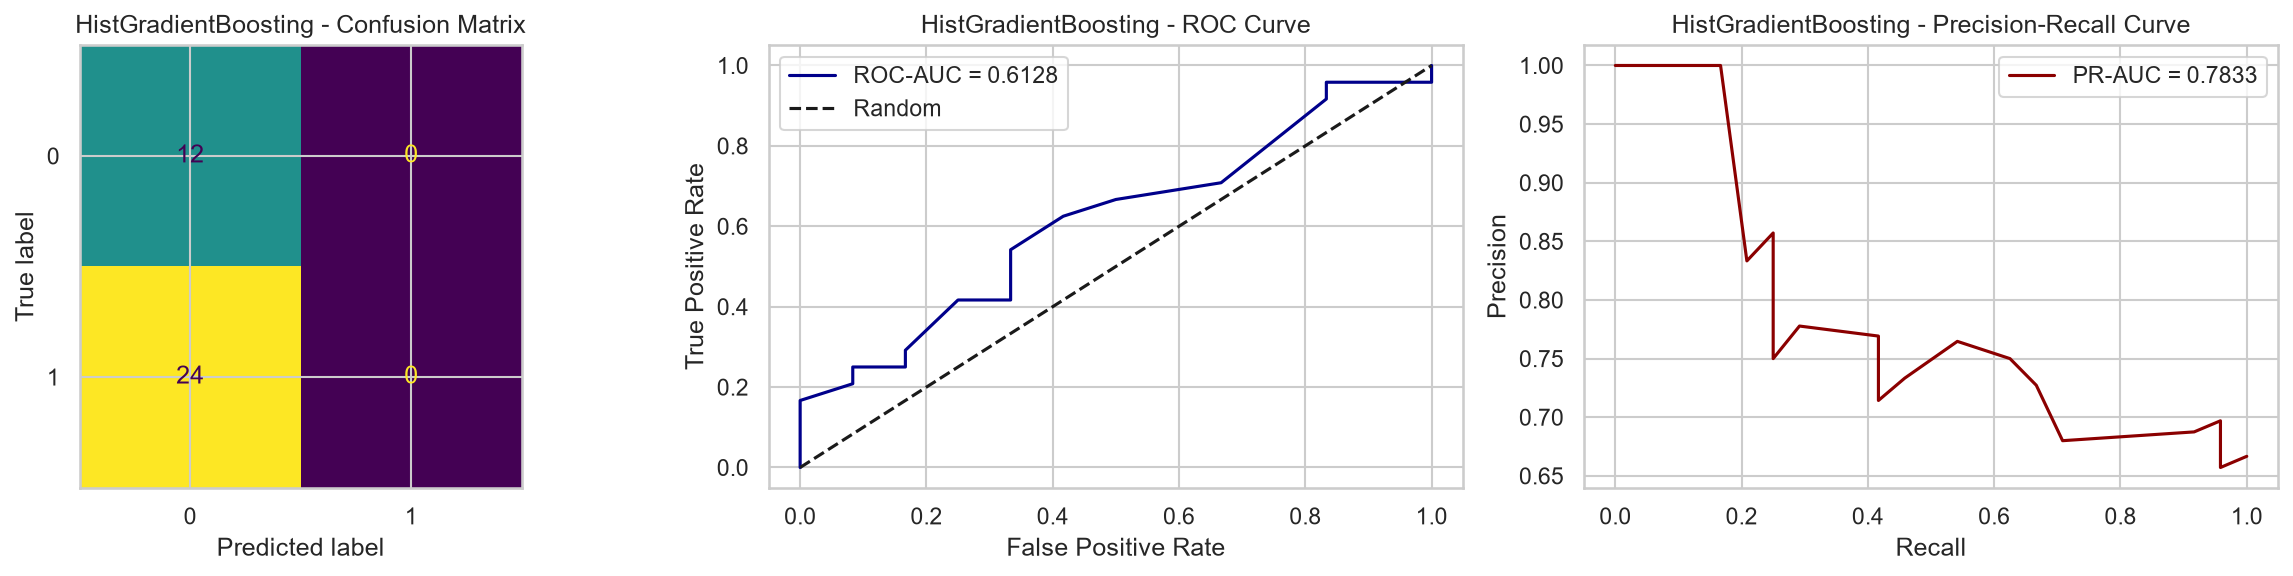

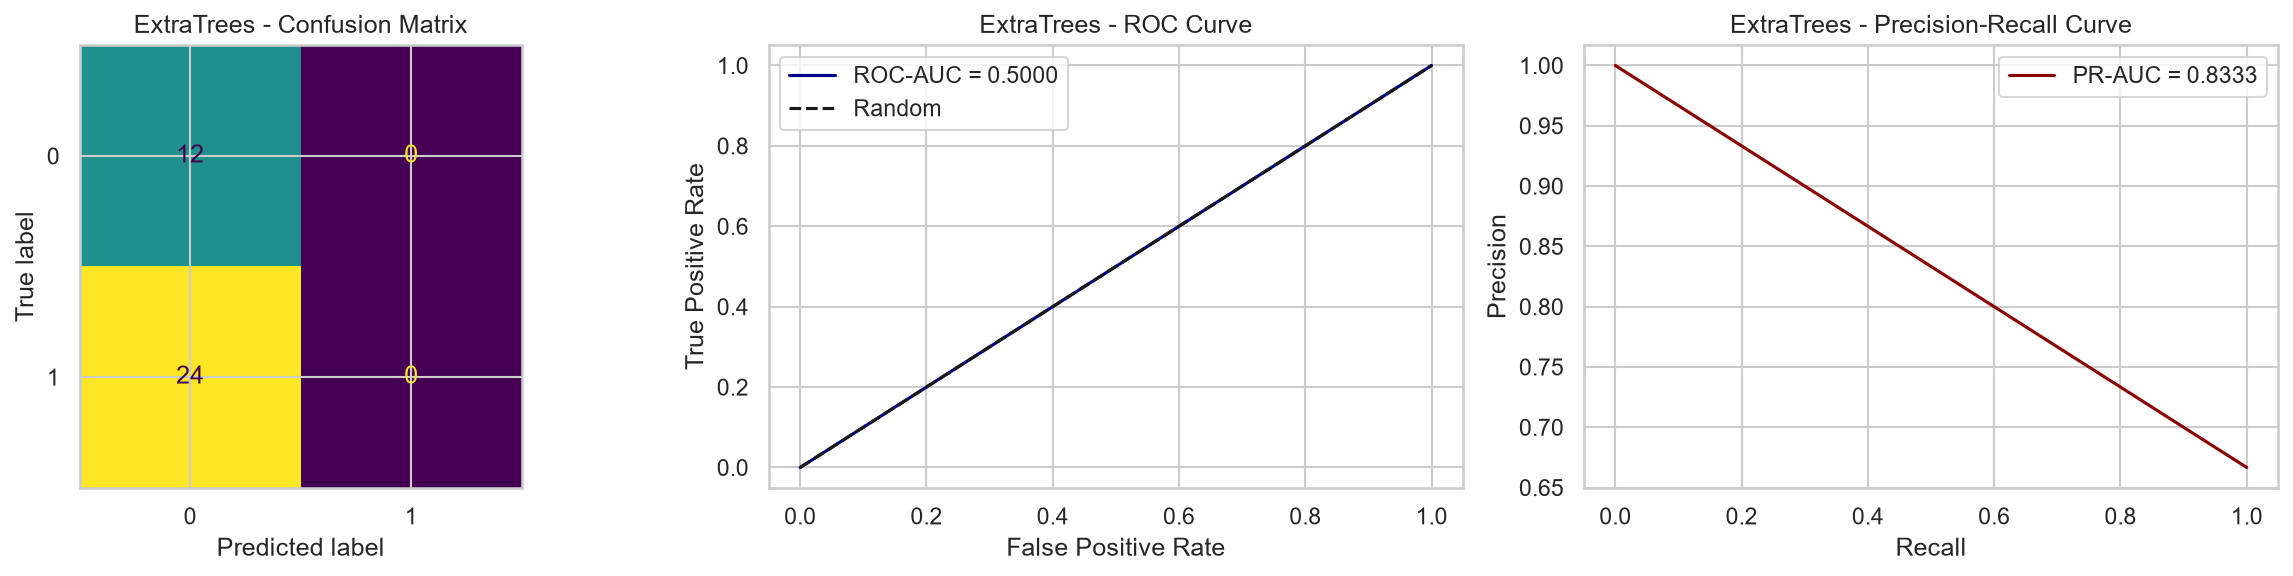

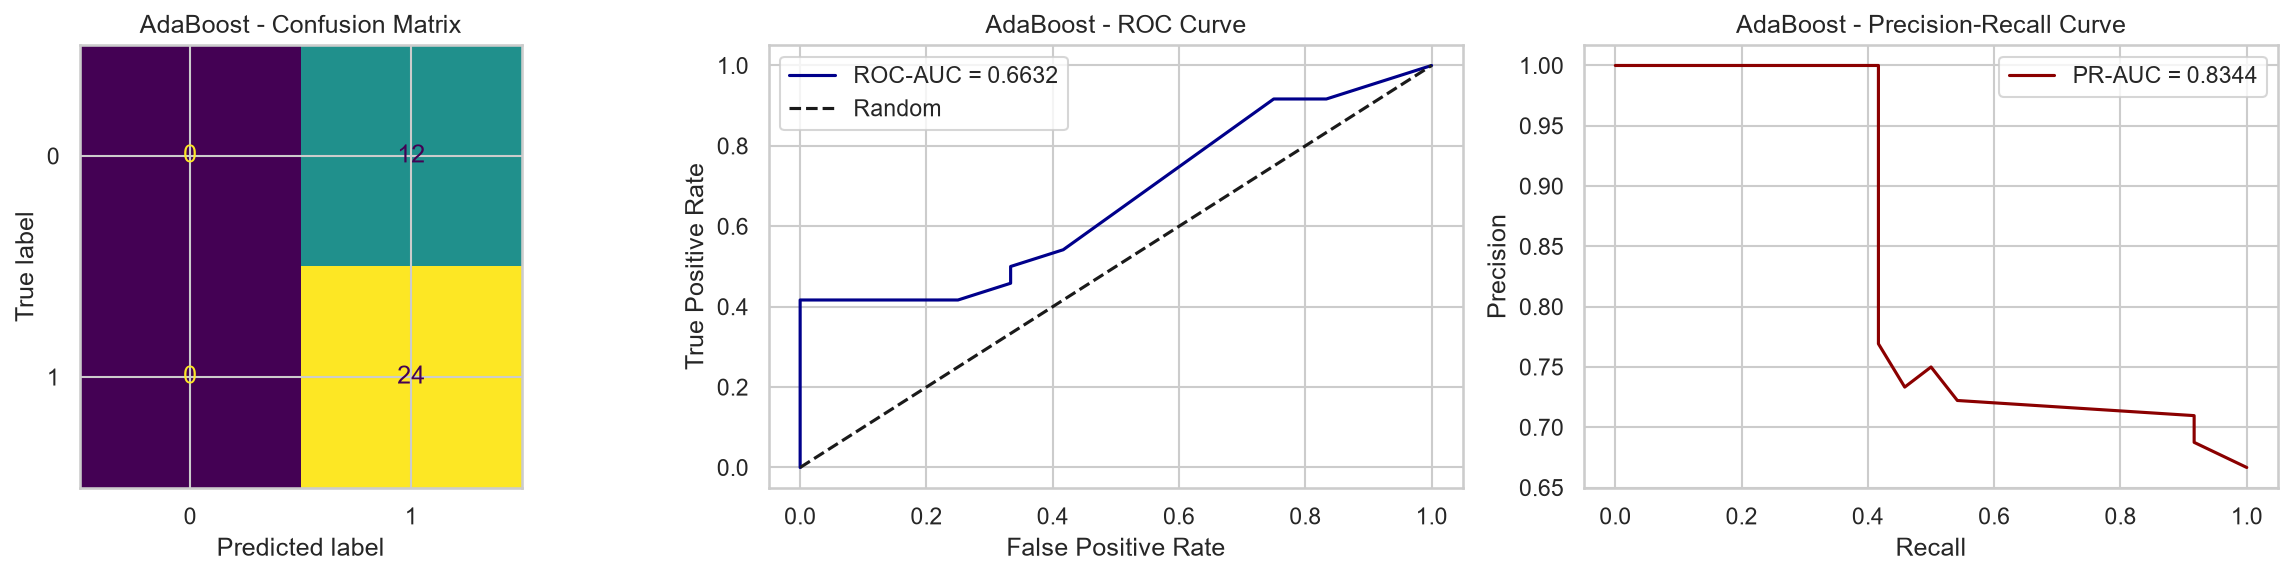

In [5]:
summary_records = []

for name in models:
    proba = oof_probs[name]
    pred = (proba >= THRESHOLD).astype(int)
    
    acc = accuracy_score(oof_true, pred)
    bal_acc = balanced_accuracy_score(oof_true, pred)
    cm = confusion_matrix(oof_true, pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    
    fpr_arr, tpr_arr, _ = roc_curve(oof_true, proba)
    roc_auc_val = auc(fpr_arr, tpr_arr)
    
    prec_arr, rec_arr, _ = precision_recall_curve(oof_true, proba)
    pr_auc_val = auc(rec_arr, prec_arr)
    mcc_val = matthews_corrcoef(oof_true, pred)
    
    summary_records.append({
        "Model": name,
        "Accuracy": acc,
        "Balanced_Acc": bal_acc,
        "ROC-AUC": roc_auc_val,
        "PR-AUC": pr_auc_val,
        "MCC": mcc_val,
        "TPR (Recall)": tpr,
        "FPR": fpr,
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn
    })
    
    print(f"\n{'='*60}")
    print(f"DIAGNOSTICS: {name.upper()} (Cutoff = {THRESHOLD})")
    print(f"{'='*60}")
    print(f"Accuracy: {acc:.4f} | Balanced Acc: {bal_acc:.4f} | ROC-AUC: {roc_auc_val:.4f} | PR-AUC: {pr_auc_val:.4f} | MCC: {mcc_val:.4f}")
    print(f"TPR (Recall): {tpr:.4f} | FPR: {fpr:.4f}")
    print("\nClassification Report:")
    print(classification_report(oof_true, pred, zero_division=0))
    
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 4))
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
    disp.plot(ax=ax1, cmap="viridis", colorbar=False)
    ax1.set_title(f"{name} - Confusion Matrix")
    
    ax2.plot(fpr_arr, tpr_arr, label=f"ROC-AUC = {roc_auc_val:.4f}", color="darkblue")
    ax2.plot([0, 1], [0, 1], "k--", label="Random")
    ax2.set_xlabel("False Positive Rate")
    ax2.set_ylabel("True Positive Rate")
    ax2.set_title(f"{name} - ROC Curve")
    ax2.legend()
    ax2.grid(True)
    
    ax3.plot(rec_arr, prec_arr, label=f"PR-AUC = {pr_auc_val:.4f}", color="darkred")
    ax3.set_xlabel("Recall")
    ax3.set_ylabel("Precision")
    ax3.set_title(f"{name} - Precision-Recall Curve")
    ax3.legend()
    ax3.grid(True)
    
    plt.tight_layout()
    plt.show()


## 4. Master Diagnostic Summary Comparison


In [6]:
summary_df = pd.DataFrame(summary_records).sort_values(by="PR-AUC", ascending=False)
print("=== MASTER BASELINE MODEL DIAGNOSTICS (THRESHOLD = 0.10) ===")
display(summary_df)

best_model = summary_df.iloc[0]
print(f"\nTOP PERFORMING CLASSIFIER: {best_model['Model']}")
print(f"PR-AUC: {best_model['PR-AUC']:.4f} | ROC-AUC: {best_model['ROC-AUC']:.4f} | Balanced Acc: {best_model['Balanced_Acc']:.4f} | TPR: {best_model['TPR (Recall)']:.4f}")


=== MASTER BASELINE MODEL DIAGNOSTICS (THRESHOLD = 0.10) ===
                  Model  Accuracy  Balanced_Acc   ROC-AUC  ...  TP  FP  FN  TN
5              AdaBoost  0.666667           0.5  0.663194  ...  24  12   0   0
1          DecisionTree  0.333333           0.5  0.500000  ...   0   0  24  12
4            ExtraTrees  0.333333           0.5  0.500000  ...   0   0  24  12
2          RandomForest  0.333333           0.5  0.500000  ...   0   0  24  12
3  HistGradientBoosting  0.333333           0.5  0.612847  ...   0   0  24  12
0    LogisticRegression  0.333333           0.5  0.545139  ...   0   0  24  12

[6 rows x 12 columns]

TOP PERFORMING CLASSIFIER: AdaBoost
PR-AUC: 0.8344 | ROC-AUC: 0.6632 | Balanced Acc: 0.5000 | TPR: 1.0000


## 5. Multi-Model Overlay ROC & PR Curves


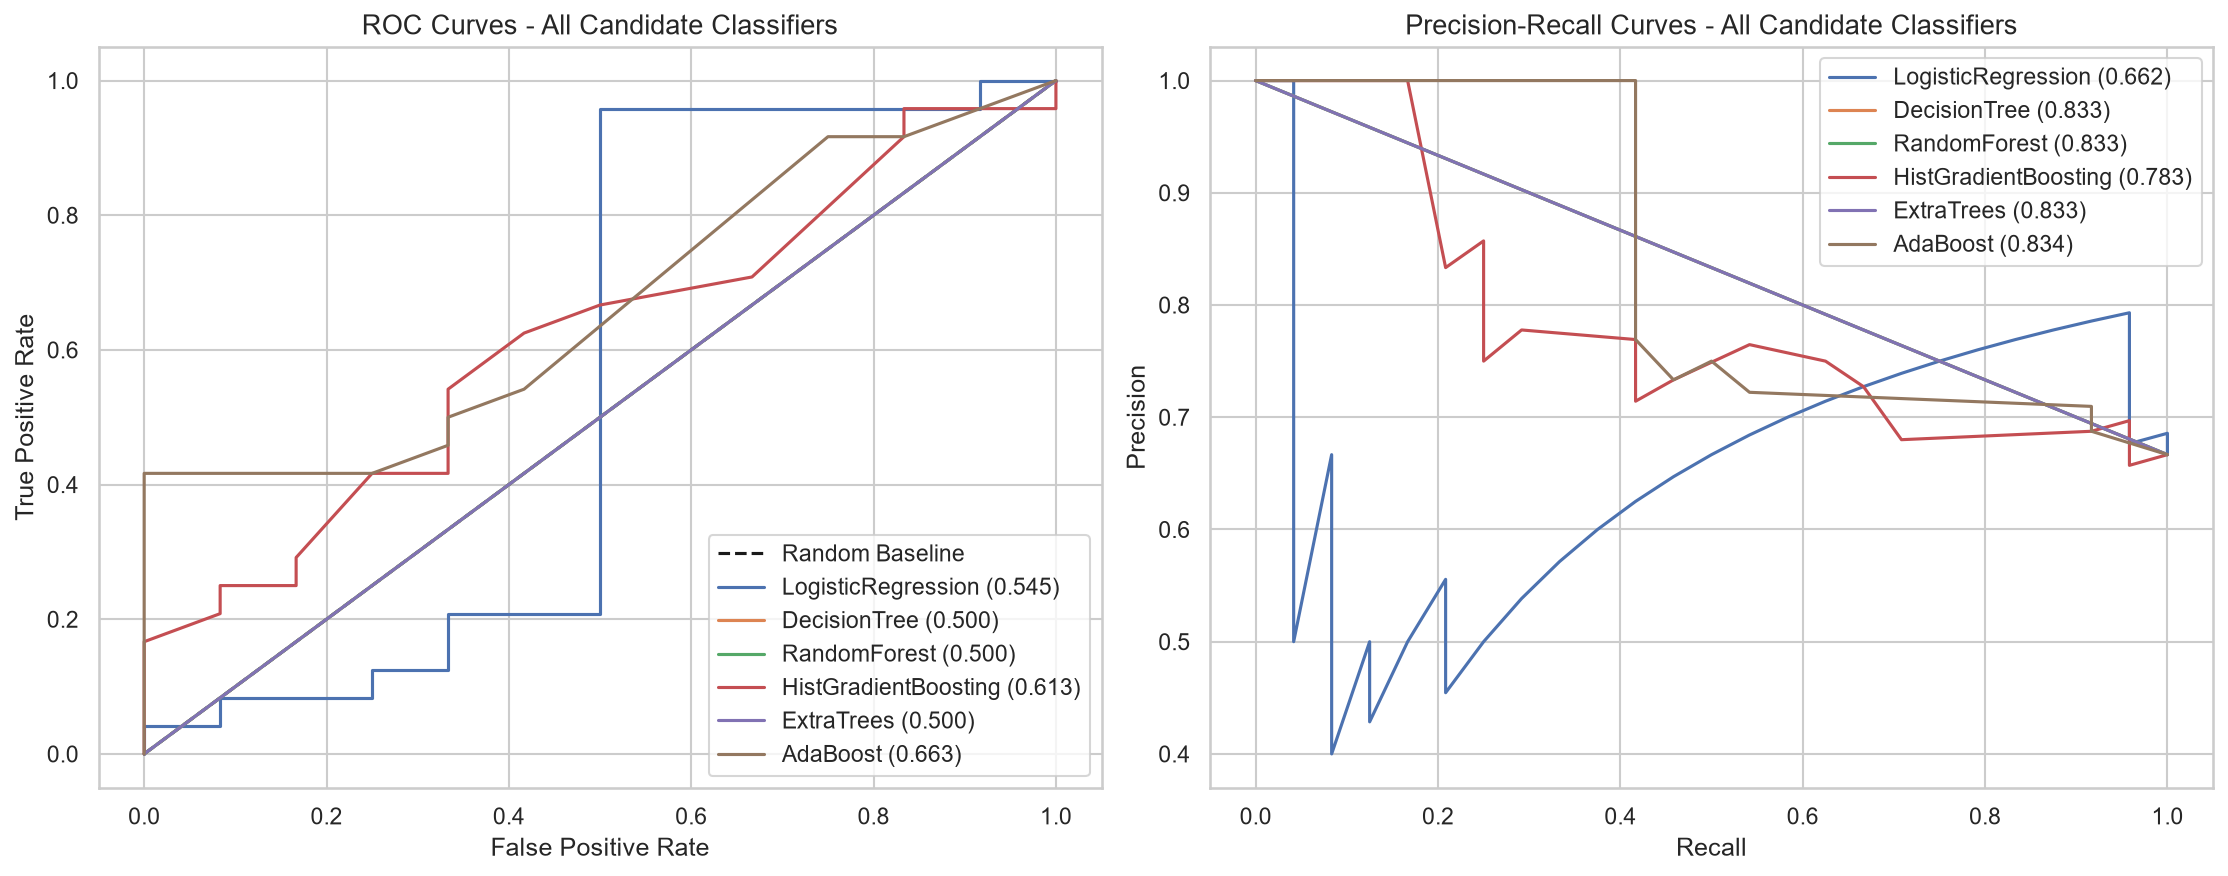

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ax1.plot([0, 1], [0, 1], "k--", label="Random Baseline")
for name in models:
    fpr_arr, tpr_arr, _ = roc_curve(oof_true, oof_probs[name])
    score = auc(fpr_arr, tpr_arr)
    ax1.plot(fpr_arr, tpr_arr, label=f"{name} ({score:.3f})")

ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax1.set_title("ROC Curves - All Candidate Classifiers", fontsize=13)
ax1.legend(loc="lower right")
ax1.grid(True)

for name in models:
    prec_arr, rec_arr, _ = precision_recall_curve(oof_true, oof_probs[name])
    score = auc(rec_arr, prec_arr)
    ax2.plot(rec_arr, prec_arr, label=f"{name} ({score:.3f})")

ax2.set_xlabel("Recall")
ax2.set_ylabel("Precision")
ax2.set_title("Precision-Recall Curves - All Candidate Classifiers", fontsize=13)
ax2.legend(loc="upper right")
ax2.grid(True)

plt.tight_layout()
plt.show()


## 6. Alert Threshold Tuning Curve (HistGradientBoosting)


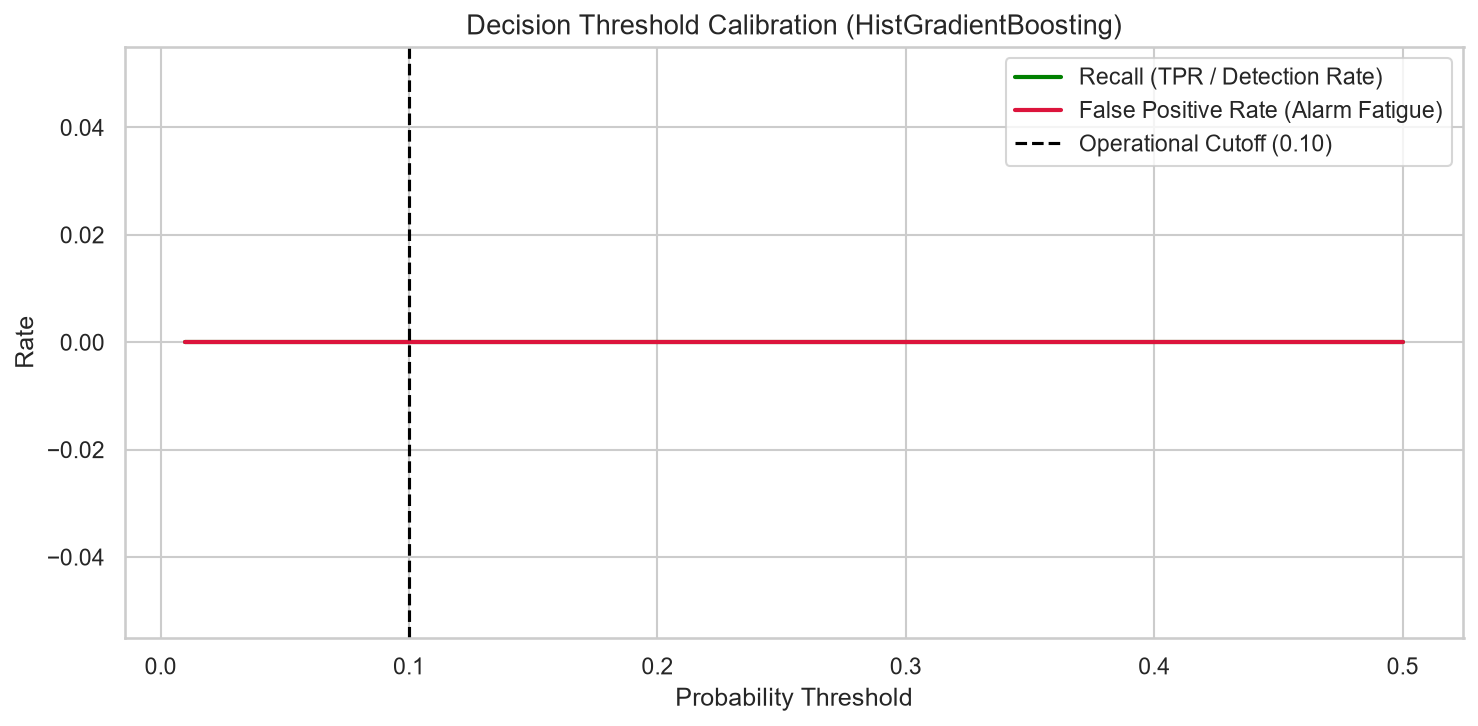

In [8]:
top_name = "HistGradientBoosting"
top_probs = oof_probs[top_name]

threshold_sweep = []
for t in np.linspace(0.01, 0.50, 50):
    p = (top_probs >= t).astype(int)
    cm = confusion_matrix(oof_true, p, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    threshold_sweep.append({"Threshold": t, "Recall (TPR)": tpr, "FPR": fpr})

sweep_df = pd.DataFrame(threshold_sweep)

plt.figure(figsize=(10, 5))
plt.plot(sweep_df["Threshold"], sweep_df["Recall (TPR)"], label="Recall (TPR / Detection Rate)", color="green", linewidth=2)
plt.plot(sweep_df["Threshold"], sweep_df["FPR"], label="False Positive Rate (Alarm Fatigue)", color="crimson", linewidth=2)
plt.axvline(0.10, color="black", linestyle="--", label="Operational Cutoff (0.10)")
plt.title(f"Decision Threshold Calibration ({top_name})", fontsize=13)
plt.xlabel("Probability Threshold")
plt.ylabel("Rate")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
